In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stat
import pylab

In [6]:
df = pd.read_csv('IO_updated.csv')
df = df.drop(['Year','Month','Unnamed: 0','xCO2','Date','Latitude [N]','Longitude [E]','Source','SSS','TEMPR'],axis=1)

In [7]:
df.head()

,SST,SALINITY,MLD,TA
0,29.768692,33.917,13.809627,2241.0
1,29.768692,33.913,13.809627,2237.0
2,29.768692,34.297,13.809627,2255.0
3,30.030148,34.328,24.409360,2252.0
4,30.030148,34.328,24.409360,2250.0


In [8]:
df = df.rename(columns={"SALINITY":"SSS"})

In [9]:
df.describe()

,SST,SSS,MLD,TA
count,1143.000000,1139.000000,1143.000000,1139.000000
mean,28.491450,34.060927,18.203838,2241.977614
std,1.662029,2.309026,9.853442,127.790560
min,23.588457,20.585300,10.376294,1631.338989
25%,27.564165,32.895050,11.902219,2172.910000
50%,28.588123,33.950200,14.191108,2229.676514
75%,29.702695,35.984100,20.828884,2339.150000
max,32.728630,38.156000,66.682945,2517.617899


In [11]:
df['MLD'] = np.log(df['MLD'])

In [12]:
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()

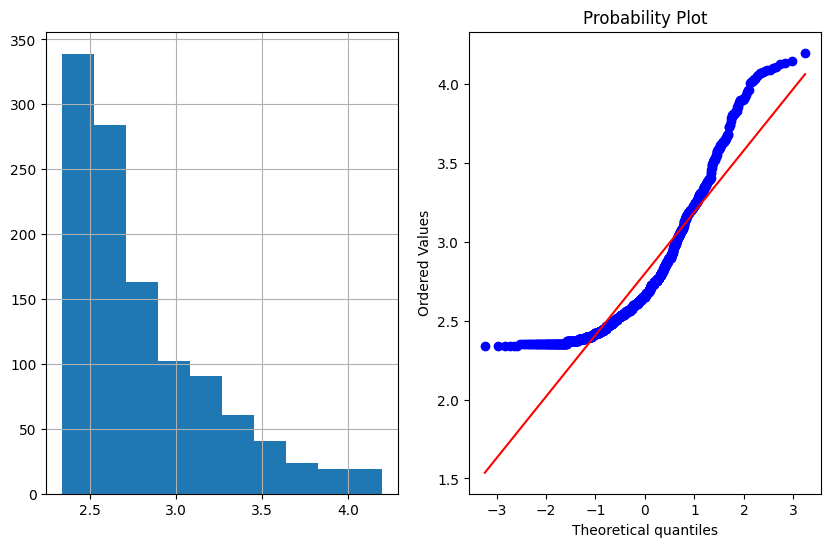

In [13]:
plot_data(df,'MLD')

In [8]:
df.head()

,SST,SSS,MLD,TA
0,29.768692,33.766335,2.625366,2241.0
1,29.768692,33.766335,2.625366,2237.0
2,29.768692,33.766335,2.625366,2255.0
3,30.030148,34.594740,3.194967,2252.0
4,30.030148,34.594740,3.194967,2250.0


In [14]:
df.isnull().sum()

SST    0
SSS    4
MLD    0
TA     4
dtype: int64

In [15]:
df['SSS'] = df['SSS'].fillna(df['SSS'].median())

# df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# df['CHLA'] = df['CHLA'].fillna(df['CHLA'].median())

# df['MLD'] = df['MLD'].fillna(df['MLD'].median())

# df['pCO2'] = df['pCO2'].fillna(df['pCO2'].median())

df['TA'] = df['TA'].fillna(df['TA'].median())

df.isnull().sum()

SST    0
SSS    0
MLD    0
TA     0
dtype: int64

In [16]:
upper_limitS = df.SSS.mean() + 3*df.SSS.std()
upper_limitT = df.SST.mean() + 3*df.SST.std()
# upper_limitCHL = df.CHLA.mean() + 3*df.CHLA.std()
upper_limitMLD = df.MLD.mean() + 3*df.MLD.std()
# upper_limitpCO2 = df.pCO2.mean() + 3*df.pCO2.std()
upper_limitTA = df.TA.mean() + 3*df.TA.std()
print(upper_limitS,upper_limitT,upper_limitMLD,upper_limitTA)

40.9755015881705 33.47753662971197 4.049868525035682 2624.640462866108


In [17]:
lower_limitS = df.SSS.mean() - 3*df.SSS.std()
lower_limitT = df.SST.mean() - 3*df.SST.std()
# lower_limitCHL = df.CHLA.mean() - 3*df.CHLA.std()
lower_limitMLD = df.MLD.mean() - 3*df.MLD.std()
# lower_limitpCO2 = df.pCO2.mean() - 3*df.pCO2.std()
lower_limitTA = df.TA.mean() - 3*df.TA.std()

print(lower_limitS,lower_limitT,lower_limitMLD,lower_limitTA)

27.145577045297117 23.505363706246037 1.5503355915802572 1859.228669042903


In [18]:
df1 = df[((df.SSS<upper_limitS) & (df.SSS>lower_limitS)) 
         & ((df.SST<upper_limitT) & (df.SST>lower_limitT)) 
#         & ((df.CHLA<upper_limitCHL) & (df.CHLA>lower_limitCHL))
         & ((df.MLD<upper_limitMLD) & (df.MLD>lower_limitMLD))
#          & ((df.pCO2<upper_limitpCO2) & (df.pCO2>lower_limitpCO2))
         & ((df.TA<upper_limitTA) & (df.TA>lower_limitTA))]

In [19]:
df1.describe()

,SST,SSS,MLD,TA
count,1106.000000,1106.000000,1106.000000,1106.000000
mean,28.530840,34.256704,2.791231,2248.224530
std,1.646005,1.719317,0.393521,111.978029
min,23.588457,27.398000,2.339524,1889.386597
25%,27.641071,32.986900,2.489464,2176.364000
50%,28.622913,33.977550,2.663311,2230.135651
75%,29.737694,35.977825,3.025291,2338.928750
max,32.728630,38.156000,4.033519,2517.617899


In [20]:
df1.columns

Index(['SST', 'SSS', 'MLD', 'TA'], dtype='object')

In [21]:
# df1.to_csv("Outlier_removed.csv",index=False)

In [22]:
romsrun_climatology.shX,y = df1.iloc[:,:-1],df1.iloc[:,-1]

In [23]:
X.head()

,SST,SSS,MLD
0,29.768692,33.917,2.625366
1,29.768692,33.913,2.625366
2,29.768692,34.297,2.625366
3,30.030148,34.328,3.194967
4,30.030148,34.328,3.194967


In [24]:
y.head()

0    2241.0
1    2237.0
2    2255.0
3    2252.0
4    2250.0
Name: TA, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
X_train.to_csv("X_train_42r.csv",index=False)
X_test.to_csv("X_test_42r.csv",index=False)
y_train.to_csv("y_train_42r.csv",index=False)
y_test.to_csv("y_test_42r.csv",index=False)

In [22]:
y.head()

0    2241.0
1    2237.0
2    2255.0
3    2252.0
4    2250.0
Name: TA, dtype: float64

In [23]:
import numpy as np

In [24]:
np.random.seed(42)
a = np.random.randint(1000,size=200)


In [25]:
for i in range(len(a)):
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=a[i])
    X_train.to_csv(f"/home/apurva/Documents/INCOIS_work/NN_study/TA_IO/TA_revised/ensemble_train_test/X_train_{i+1}.csv",index=False)
    X_test.to_csv(f"/home/apurva/Documents/INCOIS_work/NN_study/TA_IO/TA_revised/ensemble_train_test/X_test_{i+1}.csv",index=False)
    y_train.to_csv(f"/home/apurva/Documents/INCOIS_work/NN_study/TA_IO/TA_revised/ensemble_train_test/y_train_{i+1}.csv",index=False)
    y_test.to_csv(f"/home/apurva/Documents/INCOIS_work/NN_study/TA_IO/TA_revised/ensemble_train_test/y_test_{i+1}.csv",index=False)
    print("Done")

Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done


In [26]:
X_train.head()

,SST,SSS,MLD
178,29.104496,32.956940,2.339524
484,28.681875,32.432020,2.463821
1052,28.232155,33.063755,2.641805
465,29.598164,33.391827,2.652616
634,29.558610,31.843012,2.410475
